This script takes a single 2D TIFF frame, extracts a region of interest (ROI), removes a smooth background, and then uses juwavelet to identify and visualize the main gravity‐wave packets.

Pipeline:

1. Load the full TIFF as a 2D float32 array and compute the global mean and sigma.
2. Build a full-frame preview:
   - Mask pixels outside mean ± (SIGMA_FACTOR · σ).
   - Display the masked image with a fixed color range and draw the ROI rectangle.
3. Extract the ROI using X_SLICE and Y_SLICE.
4. Apply the same global mean ± σ range filter inside the ROI (optional), and fill “invalid” pixels (outside the range) so the ROI remains a full rectangle for the CWT.
5. Remove a smooth background from the ROI:
   - Fit and subtract a 2D plane (optional).
   - Extract and subtract the first Fourier components in x and y.
   - Define the “remaining” field = original − background.
6. Apply a Hanning edge taper to the remaining field (optional), then optionally despike it using a local median / MAD filter (DESPIKE_SIZE, DESPIKE_K).
7. Make a 4-panel figure showing:
   - Original (median-subtracted).
   - Background (plane + first Fourier).
   - Remaining = original − background.
   - Remaining with edge taper (and spikes removed).
8. Preprocess the tapered, despiked field for CWT:
   - Median-center and standardize (optional).
   - Apply a small Gaussian blur (optional).
9. Run 2D continuous wavelet transform with juwavelet.decompose2d using the specified S0, DJ, JS, JT, DX, DY, ASPECT.
10. Identify wave clusters in wavelet space with utils.identify_cluster2d (CLUSTER_MIN_AMP, CLUSTER_THR).
11. Plot:
    - A decomposition overview (utils.plot_decomposition2d).
    - A FOV wavelet spectrum (orientation vs wavelength) via plot_utils.plot_fov_wavelet_spectrum.
12. For the 9 strongest clusters:
    - Reconstruct each cluster back into physical space.
    - Plot 9 standalone cluster fields (median-centered).
    - Plot 9 overlays: each cluster on top of the tapered, despiked background field.

Outputs: one full-frame preview, one 4-panel background figure, a CWT summary figure, a polar FOV spectrum, 9 standalone cluster plots, and 9 cluster-on-background overlays.


[Full] mean: 21189.07
[Full] sigma: 3920.02
[Full] Dynamic range: [19229.06, 23149.08] = mean ± 0.50·sigma
[Full] In-range count: 79570
[Full] In-range min/max: 19236.00 / 23111.00
[Full] In-range percentiles 5/50/95: 20886.00 / 21577.00 / 22246.00


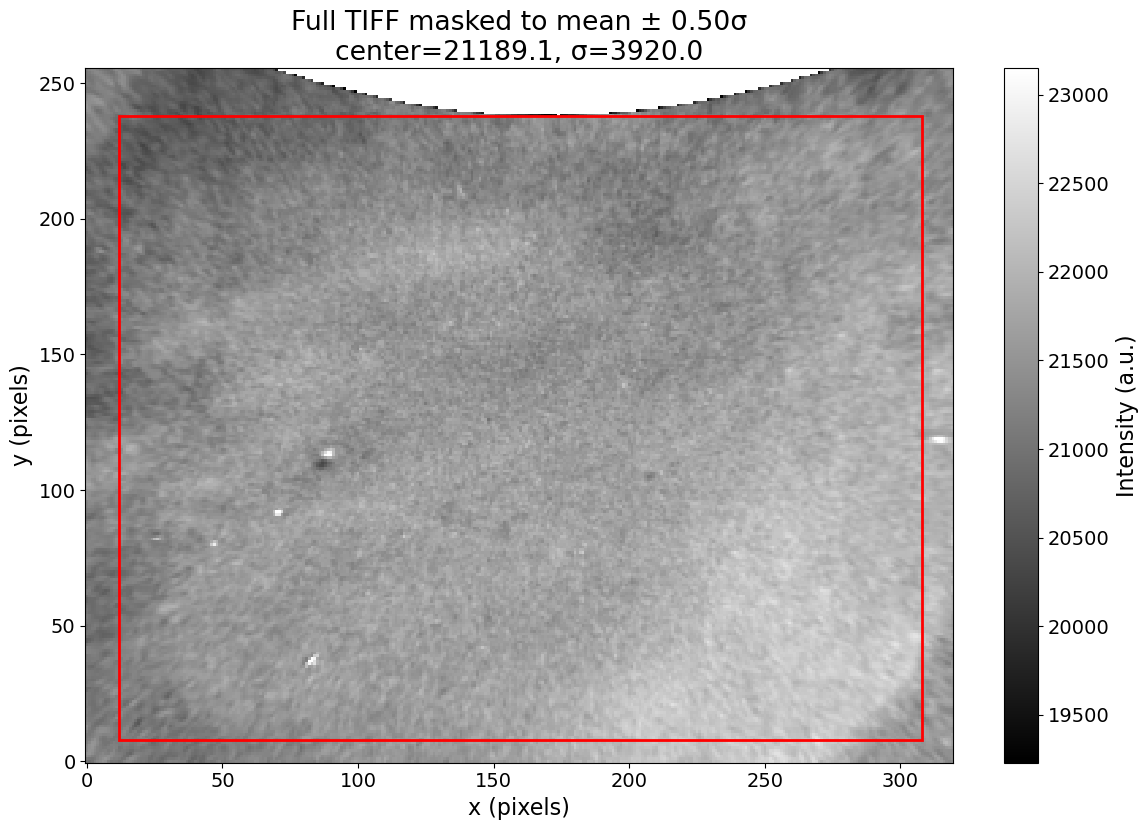

[ROI] shape: (230, 296)
[ROI] In-range count: 68073
[ROI] In-range min/max: 20272.00 / 23077.00
[ROI] In-range percentiles 5/50/95: 21031.00 / 21600.00 / 22251.00


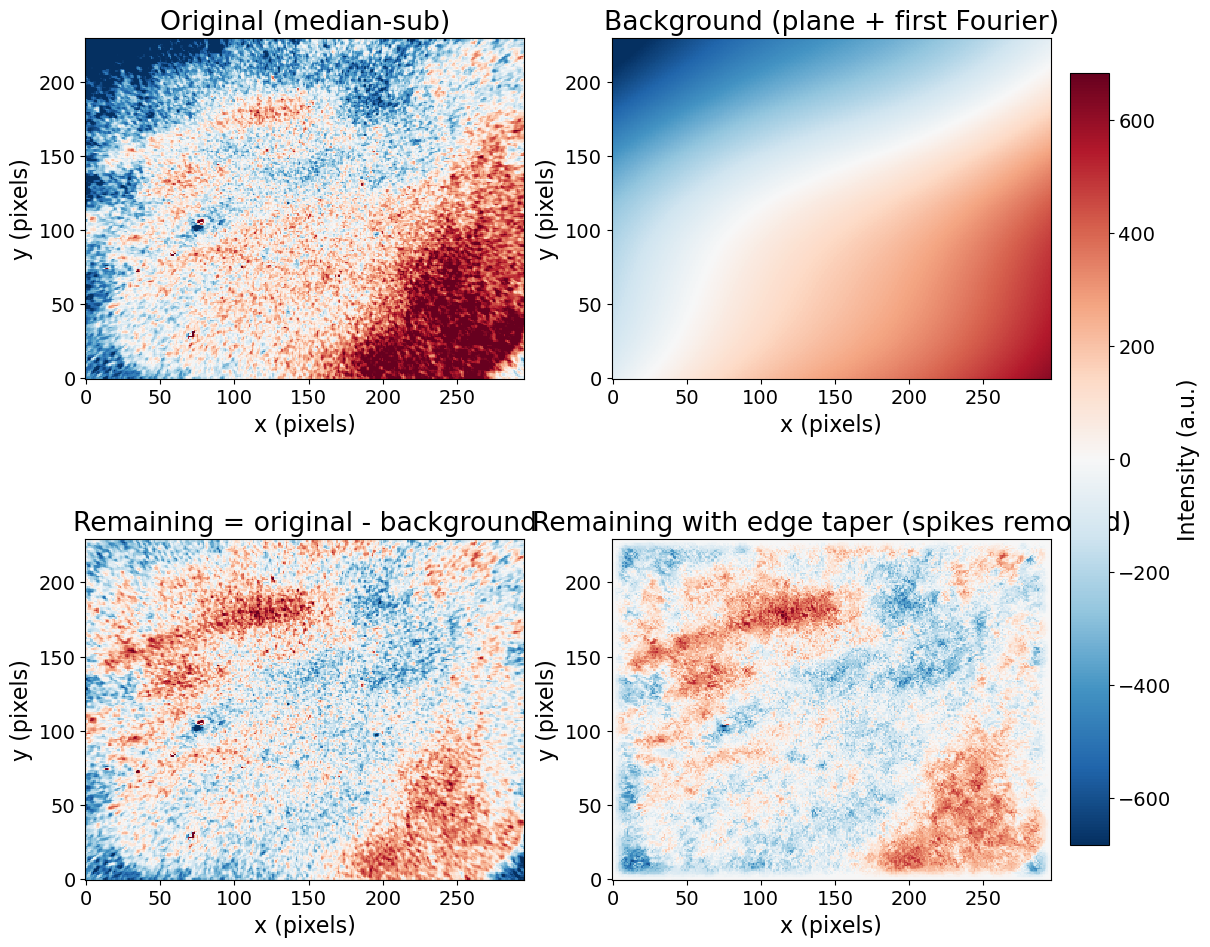

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.3562400534622131 idx= (np.int64(20), np.int64(7), np.int64(77), np.int64(60))
selected elements: 143814
------------
cluster= 1
amplitude= 0.34745421946371596 idx= (np.int64(16), np.int64(6), np.int64(35), np.int64(104))
selected elements: 28678
------------
cluster= 2
amplitude= 0.33247030538265376 idx= (np.int64(21), np.int64(6), np.int64(77), np.int64(138))
selected elements: 67839
------------
cluster= 3
amplitude= 0.318527639413684 idx= (np.int64(24), np.int64(10), np.int64(123), np.int64(55))
selected elements: 147296
------------
cluster= 4
amplitude= 0.3122719397868829 idx= (np.int64(8), np.int64(9), np.int64(28), np.int64(146))
selected elements: 7358
------------
cluster= 5
amplitude= 0.2618340243565488 idx= (np.int64(10), np.int64(17), np.int64(238), np.int64(44))
selected elements: 3417
------------
cluster= 6
amplitude= 0.2565458443756531 idx= (np.int64(16), np.int64(0), np.int64(30), np.int64(36))
selected elements: 5486


C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 48.02it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


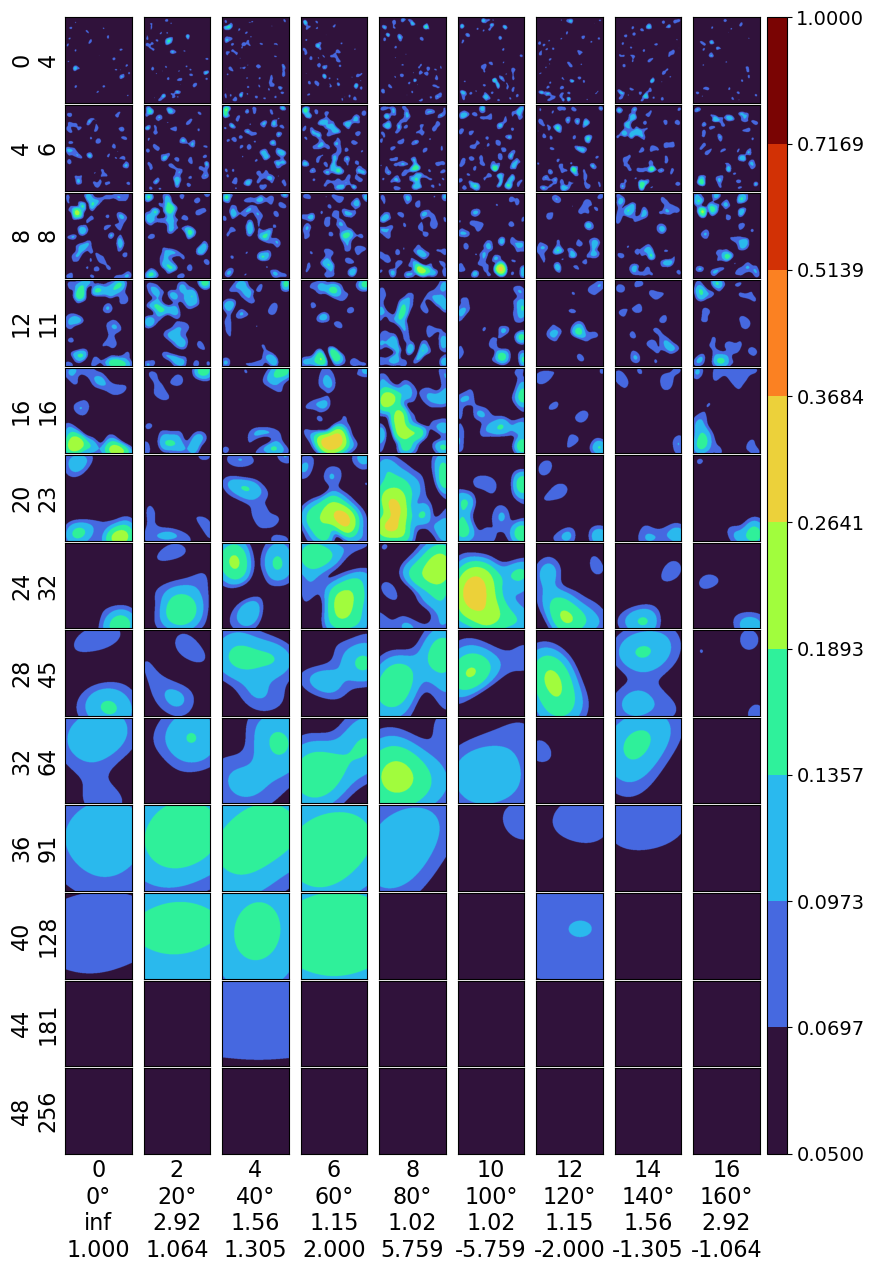

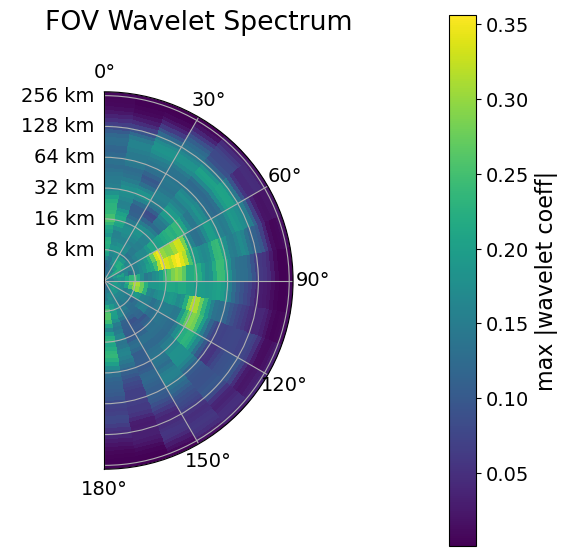

[Clusters-only] Cluster 0: amp=0.356, lamx=66.16, lamy=24.08, lam=22.63
[Clusters-only] Cluster 1: amp=0.347, lamx=32.00, lamy=18.48, lam=16.00
[Clusters-only] Cluster 2: amp=0.332, lamx=49.35, lamy=28.49, lam=24.68
[Clusters-only] Cluster 3: amp=0.319, lamx=-184.28, lamy=32.49, lam=32.00
[Clusters-only] Cluster 4: amp=0.312, lamx=130649914825562960.00, lamy=8.00, lam=8.00
[Clusters-only] Cluster 5: amp=0.262, lamx=-9.66, lamy=54.79, lam=9.51
[Clusters-only] Cluster 6: amp=0.257, lamx=16.00, lamy=inf, lam=16.00


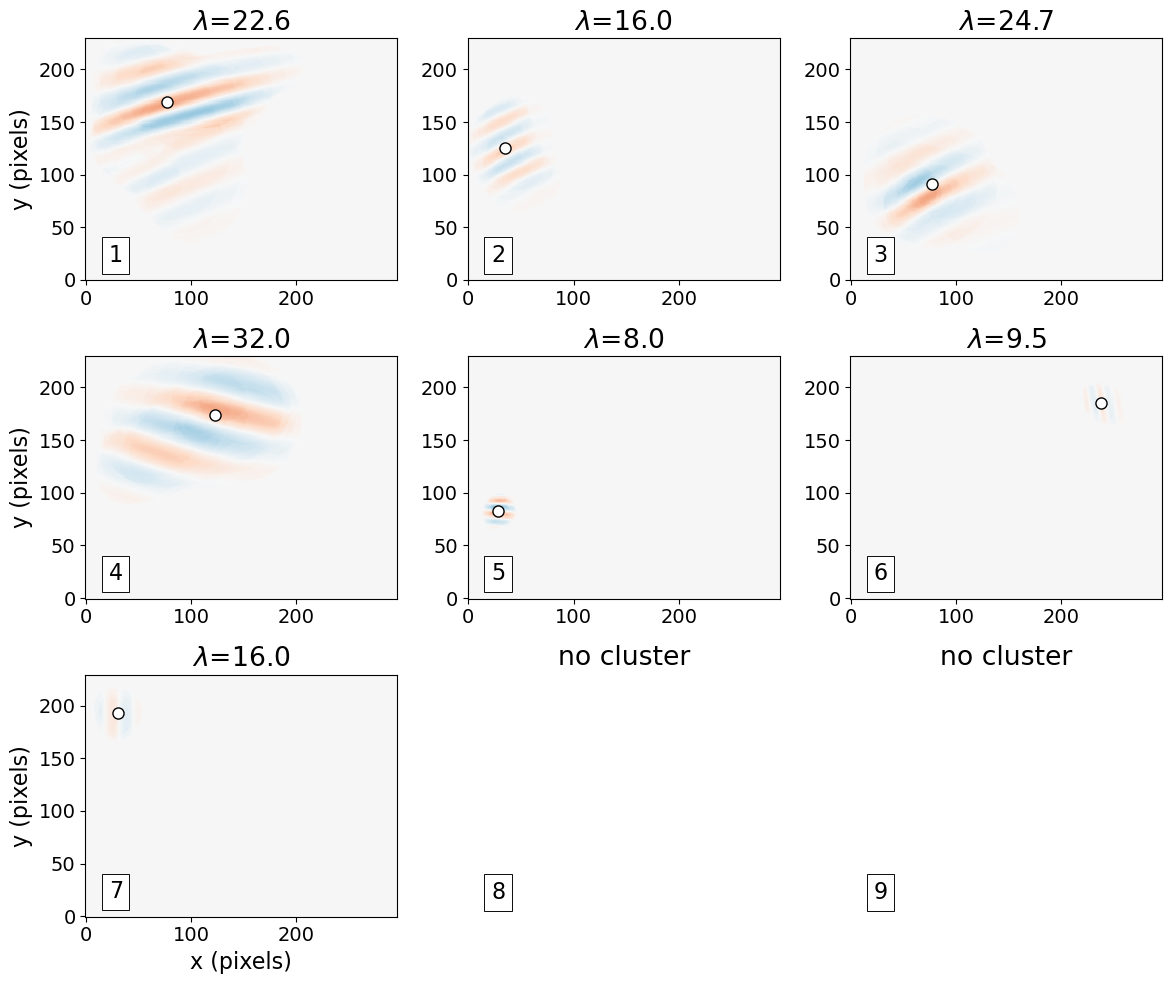

[Overlay] Cluster 0: amp=0.356, lamx=66.16, lamy=24.08, lam=22.63
[Overlay] Cluster 1: amp=0.347, lamx=32.00, lamy=18.48, lam=16.00
[Overlay] Cluster 2: amp=0.332, lamx=49.35, lamy=28.49, lam=24.68
[Overlay] Cluster 3: amp=0.319, lamx=-184.28, lamy=32.49, lam=32.00
[Overlay] Cluster 4: amp=0.312, lamx=130649914825562960.00, lamy=8.00, lam=8.00
[Overlay] Cluster 5: amp=0.262, lamx=-9.66, lamy=54.79, lam=9.51
[Overlay] Cluster 6: amp=0.257, lamx=16.00, lamy=inf, lam=16.00


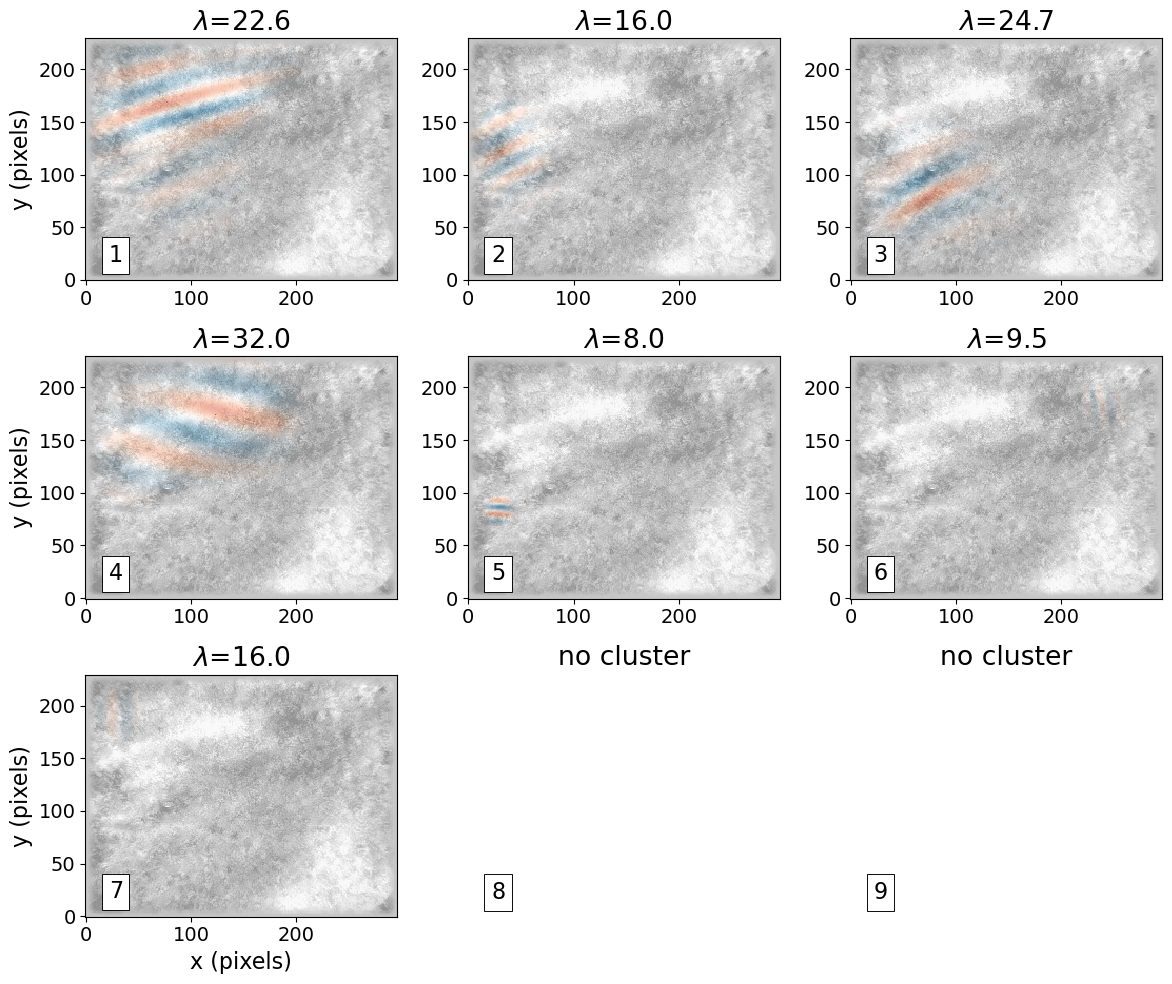

In [5]:
# Full TIFF -> ROI -> background removal -> wavelet clusters
#
# Produces:
#   1) Full TIFF preview (mean ± 0.5 sigma) with ROI rectangle
#   2) 4-panel background figure:
#        - original (median-sub)
#        - background (plane + first Fourier)
#        - remaining
#        - remaining with edge taper, spikes removed (if enabled)
#   3) Wavelet decomposition summary (utils.plot_decomposition2d)
#   4) FOV wavelet spectrum (orientation vs wavelength)
#   5) 9 standalone wavelet clusters (reconstructed fields)
#   6) 9 overlay clusters on top of the tapered remaining field (spikes removed)

from __future__ import annotations
from typing import Tuple, Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Nov7th1150\TempOH_caun1176.tif"

# ROI (pixel slices) for analysis. Set to None to use full image.
X_SLICE: Optional[slice] = slice(12, 308)
Y_SLICE: Optional[slice] = slice(18, 248)

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.5
APPLY_RANGE_FILTER = True   # use that [lo, hi] range for ROI filtering

# How to fill invalid pixels before CWT (to keep rectangular grid)
# choices: "median", "mean", "zero"
FILL_INVALID_FOR_CWT = "median"

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 1        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 7            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.2           # thr for identify_cluster2d

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# Helpers
# --------------------------
def load_tiff(
    path: str,
) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def make_range_mask(Z: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """True where value is inside [lo, hi]."""
    return (Z >= lo) & (Z <= hi)


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def fill_invalid(Z: np.ndarray, valid_mask: Optional[np.ndarray], how: str) -> np.ndarray:
    """Fill invalid pixels to keep rectangular grid before CWT."""
    out = Z.copy()
    if valid_mask is None:
        return out
    inv = ~valid_mask
    if not np.any(inv):
        return out
    if how == "median":
        val = float(np.median(out[~inv])) if np.any(~inv) else float(np.median(out))
    elif how == "mean":
        val = float(np.mean(out[~inv])) if np.any(~inv) else float(np.mean(out))
    elif how == "zero":
        val = 0.0
    else:
        raise ValueError("FILL_INVALID_FOR_CWT must be 'median', 'mean', or 'zero'")
    out[inv] = val
    return out


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.

    Parameters
    ----------
    Z : 2D array
    size : int
        Window size for local median (3, 5, ...)
    k : float
        Threshold in units of local MAD (~sigma). Larger = more tolerant.

    Returns
    -------
    2D array, same shape as Z
    """
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      interior stays ~1
      transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Main pipeline
# --------------------------
def run_pipeline():
    # 1) Load full TIFF
    full = load_tiff(TIFF_PATH)
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    # 2) Compute mean/std once on the full image, use ±0.5σ everywhere
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean: {center:.2f}")
    print(f"[Full] sigma: {sigma:.2f}")
    print(f"[Full] Dynamic range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # 3) Full-image preview with that same range, and ROI rectangle
    mask_full = make_range_mask(full, lo, hi)
    preview = full.copy().astype(float)
    preview[~mask_full] = np.nan

    vals_full = preview[np.isfinite(preview)]
    if vals_full.size > 0:
        print(f"[Full] In-range count: {vals_full.size}")
        print(f"[Full] In-range min/max: {np.nanmin(vals_full):.2f} / {np.nanmax(vals_full):.2f}")
        p5f, p50f, p95f = np.nanpercentile(vals_full, [5, 50, 95])
        print(f"[Full] In-range percentiles 5/50/95: {p5f:.2f} / {p50f:.2f} / {p95f:.2f}")
    else:
        print("[Full] Warning: no pixels within mean ± 0.5 sigma")

    disp_prev = np.clip(preview, lo, hi)

    # Flip y for display
    y_full_flip = y_full[::-1]

    fig_prev, ax_prev = plt.subplots()
    im_prev = ax_prev.pcolormesh(
        x_full,
        y_full_flip,
        disp_prev,
        shading="auto",
        cmap="gray",
        vmin=lo,
        vmax=hi,
    )
    cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
    cb_prev.set_label("Intensity (a.u.)")
    ax_prev.set_xlabel("x (pixels)")
    ax_prev.set_ylabel("y (pixels)")
    ax_prev.set_title(f"Full TIFF masked to mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}")
    ax_prev.set_aspect("equal", adjustable="box")

    # ROI rectangle in full-image coordinates
    ysl_full = Y_SLICE if Y_SLICE is not None else slice(0, ny_full)
    xsl_full = X_SLICE if X_SLICE is not None else slice(0, nx_full)

    x0 = 0 if xsl_full.start is None else xsl_full.start
    x1 = nx_full if xsl_full.stop is None else xsl_full.stop
    y0 = 0 if ysl_full.start is None else ysl_full.start
    y1 = ny_full if ysl_full.stop is None else ysl_full.stop

    # Map to flipped-y display coords: [y0, y1) -> [ny_full - y1, ny_full - y0)
    y0_disp = ny_full - y1
    y1_disp = ny_full - y0

    rect = patches.Rectangle(
        (x0, y0_disp),
        x1 - x0,
        y1_disp - y0_disp,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax_prev.add_patch(rect)

    plt.tight_layout()
    plt.show(fig_prev)

    # 4) Clip to ROI
    ysl = Y_SLICE if Y_SLICE is not None else slice(None, None)
    xsl = X_SLICE if X_SLICE is not None else slice(None, None)

    raw = full[ysl, xsl]
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]   # flip y for display

    print(f"[ROI] shape: {raw.shape}")

    # 5) Range filter for ROI, using the SAME [lo, hi] from full image
    mask = None
    if APPLY_RANGE_FILTER:
        mask = make_range_mask(raw, lo, hi)
        vals_roi = raw[mask]
        if vals_roi.size > 0:
            print(f"[ROI] In-range count: {vals_roi.size}")
            print(f"[ROI] In-range min/max: {np.nanmin(vals_roi):.2f} / {np.nanmax(vals_roi):.2f}")
            p5r, p50r, p95r = np.nanpercentile(vals_roi, [5, 50, 95])
            print(f"[ROI] In-range percentiles 5/50/95: {p5r:.2f} / {p50r:.2f} / {p95r:.2f}")
        else:
            print("[ROI] Warning: no pixels in [mean ± 0.5σ]")

    # 6) Prepare data for CWT: fill removed pixels to keep rectangular grid
    filled = fill_invalid(raw, mask, FILL_INVALID_FOR_CWT) if APPLY_RANGE_FILTER else raw

    # No despike here; we will despike after tapering.
    proc0 = filled.copy()

    # 7) Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # 8) Apply edge taper on remaining field (for CWT and plotting)
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Remove spikes AFTER tapering (optional)
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel
    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # 9) 4-panel background figure
    fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    axes_bg_flat = axs_bg.flatten()

    imgs_bg = [
        (orig_c, "Original (median-sub)"),
        (bg_c, "Background (plane + first Fourier)"),
        (rem_c, "Remaining = original - background"),
        (rem_tapered_c, f"Remaining with edge taper (spikes removed)"),
    ]

    im_bg = None
    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im_bg = ax.pcolormesh(
            x1d,
            y1d,
            Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_aspect("equal")

    cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical",
                              fraction=0.04, pad=0.02)
    cbar_bg.set_label("Intensity (a.u.)")

    plt.show(fig_bg)

    # 10) Preprocess for CWT only (standardize + blur) on tapered + de-spiked field
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # 11) Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # 12) Overview CWT plot
    cmap_cwt = matplotlib.cm.turbo
    norm_cwt = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap_cwt.N
    )
    fig_cwt, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2,
                                            cmap=cmap_cwt, norm=norm_cwt)
    plt.show(fig_cwt)

    # 13) FOV wavelet spectrum
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # Background image for overlays: tapered remaining (spikes removed), centered
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    # --------------------------
    # Figure 1: 9 standalone clusters
    # --------------------------
    fig1, axs1 = plt.subplots(3, 3, figsize=(12, 10))
    axes1_flat = axs1.flatten()

    opts_img_cluster = {"cmap": "RdBu_r", "vmin": -0.8, "vmax": 0.8, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes1_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes1_flat, biggest):
            # Reconstruct cluster
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]          # (s_idx, t_idx, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(rf"$\lambda$={_fmt(lam)}")
            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img_cluster)
            ax.set_aspect("equal", adjustable="box")
            
            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )
            
            print(
                f"[Clusters-only] Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # Hide unused axes
        for ax in axes1_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    for ax in axs1[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs1[:, 0]:
        ax.set_ylabel("y (pixels)")

    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }
    for i, ax in enumerate(axes1_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig1.tight_layout()
    plt.show(fig1)

    # --------------------------
    # Figure 2: 9 overlays (cluster on tapered field)
    # --------------------------
    fig2, axs2 = plt.subplots(3, 3, figsize=(12, 10))
    axes2_flat = axs2.flatten()

    if n_clusters == 0:
        for ax in axes2_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        cl_vmin, cl_vmax = -0.6, 0.6

        for ax, kcl in zip(axes2_flat, biggest):
            # Background: tapered remaining field (centered, spikes removed), grayscale
            ax.pcolormesh(
                x1d,
                y1d,
                bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            # Reconstruct cluster again
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(rf"$\lambda$={_fmt(lam)}")
            ax.set_aspect("equal", adjustable="box")

            print(
                f"[Overlay] Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # Hide unused axes
        for ax in axes2_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    for ax in axs2[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs2[:, 0]:
        ax.set_ylabel("y (pixels)")

    for i, ax in enumerate(axes2_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


Loaded 11 frames, shape = (11, 256, 320)
center: 21161.81, sigma: 3918.61
use range: [19202.50, 23121.11]


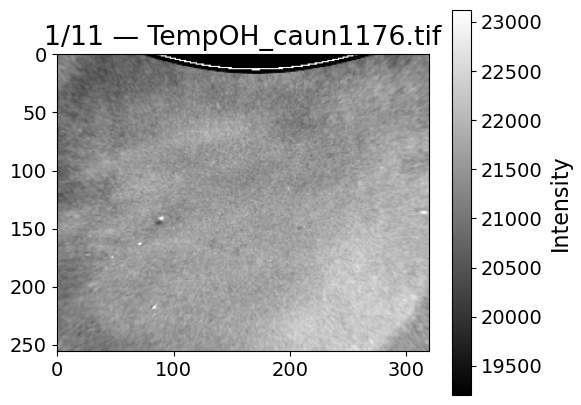

In [7]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --------------------
# User settings
# --------------------
FOLDER = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Nov7th1150"
FACTOR = 0.5  # center ± FACTOR * sigma range


# Load all TIFFs into memory
files = sorted(glob.glob(os.path.join(FOLDER, "*.tif")))
if not files:
    raise FileNotFoundError("No TIFFs found in folder.")

frames = []
for f in files:
    img = tiff.imread(f)
    frames.append(img.astype(np.float32))

data = np.stack(frames, axis=0)   # shape: (N, ny, nx)

print(f"Loaded {len(files)} frames, shape = {data.shape}")

# Compute global stats for display
sample = data.ravel()
center = float(np.mean(sample))
sigma = float(np.std(sample))

vmin = center - FACTOR * sigma
vmax = center + FACTOR * sigma

print(f"center: {center:.2f}, sigma: {sigma:.2f}")
print(f"use range: [{vmin:.2f}, {vmax:.2f}]")

# --------------------
# Plot movie animation
# --------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    np.clip(data[0], vmin, vmax),
    cmap="gray",
    vmin=vmin, vmax=vmax,
    origin="upper"
)

title = ax.set_title(os.path.basename(files[0]))
plt.colorbar(im, ax=ax, label="Intensity")

def update(i):
    im.set_data(np.clip(data[i], vmin, vmax))
    title.set_text(f"{i+1}/{len(files)} — {os.path.basename(files[i])}")
    return im, title

anim = FuncAnimation(fig, update, frames=len(files), interval=400, blit=False)

HTML(anim.to_jshtml())


### Batch


Found 11 TIFF files in C:\Users\domin\juwavelet\examples\Waves For Anh\Nov7th1150
Output will be saved in C:\Users\domin\juwavelet\examples\Waves For Anh\Nov7th1150\wavelet_output

=== Processing TempOH_caun1176.tif ===
[Full] mean: 21189.07
[Full] sigma: 3920.02
[Full] Dynamic range: [19229.06, 23149.08] = mean ± 0.50·sigma
[Full] In-range count: 79570
[Full] In-range min/max: 19236.00 / 23111.00
[Full] In-range percentiles 5/50/95: 20886.00 / 21577.00 / 22246.00
[ROI] shape: (230, 296)
[ROI] In-range count: 68073
[ROI] In-range min/max: 20272.00 / 23077.00
[ROI] In-range percentiles 5/50/95: 21031.00 / 21600.00 / 22251.00


C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.3562400534622131 idx= (np.int64(10), np.int64(7), np.int64(77), np.int64(60))
selected elements: 75138
------------
cluster= 1
amplitude= 0.34745421946371596 idx= (np.int64(8), np.int64(6), np.int64(35), np.int64(104))
selected elements: 12041
------------
cluster= 2
amplitude= 0.3285139223498312 idx= (np.int64(11), np.int64(6), np.int64(74), np.int64(139))
selected elements: 30700
------------
cluster= 3
amplitude= 0.318527639413684 idx= (np.int64(12), np.int64(10), np.int64(123), np.int64(55))
selected elements: 50449
------------
cluster= 4
amplitude= 0.3122719397868829 idx= (np.int64(4), np.int64(9), np.int64(28), np.int64(146))
selected elements: 3518
------------
cluster= 5
amplitude= 0.278563081831461 idx= (np.int64(13), np.int64(11), np.int64(125), np.int64(60))
selected elements: 20803
------------
cluster= 6
amplitude= 0.2618340243565488 idx= (np.int64(5), np.int64(17), np.int64(238), np.int64(44))
selected elements: 1621
------------
clus

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 69.61it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


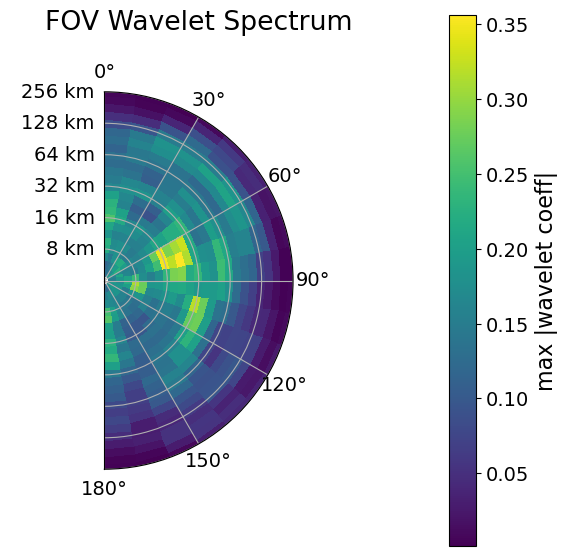

[Clusters-only] Cluster 0: amp=0.356, lamx=66.16, lamy=24.08, lam=22.63
[Clusters-only] Cluster 1: amp=0.347, lamx=32.00, lamy=18.48, lam=16.00
[Clusters-only] Cluster 2: amp=0.329, lamx=53.82, lamy=31.07, lam=26.91
[Clusters-only] Cluster 3: amp=0.319, lamx=-184.28, lamy=32.49, lam=32.00
[Clusters-only] Cluster 4: amp=0.312, lamx=130649914825562960.00, lamy=8.00, lam=8.00
[Clusters-only] Cluster 5: amp=0.279, lamx=-111.26, lamy=40.50, lam=38.05
[Clusters-only] Cluster 6: amp=0.262, lamx=-9.66, lamy=54.79, lam=9.51
[Clusters-only] Cluster 7: amp=0.257, lamx=16.00, lamy=inf, lam=16.00
[Overlay] Cluster 0: amp=0.356, lamx=66.16, lamy=24.08, lam=22.63
[Overlay] Cluster 1: amp=0.347, lamx=32.00, lamy=18.48, lam=16.00
[Overlay] Cluster 2: amp=0.329, lamx=53.82, lamy=31.07, lam=26.91
[Overlay] Cluster 3: amp=0.319, lamx=-184.28, lamy=32.49, lam=32.00
[Overlay] Cluster 4: amp=0.312, lamx=130649914825562960.00, lamy=8.00, lam=8.00
[Overlay] Cluster 5: amp=0.279, lamx=-111.26, lamy=40.50, lam=3

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.34218508722231344 idx= (np.int64(8), np.int64(7), np.int64(40), np.int64(87))
selected elements: 39391
------------
cluster= 1
amplitude= 0.3376950614874914 idx= (np.int64(11), np.int64(7), np.int64(92), np.int64(115))
selected elements: 44644
------------
cluster= 2
amplitude= 0.32466937766385123 idx= (np.int64(12), np.int64(10), np.int64(129), np.int64(50))
selected elements: 48766
------------
cluster= 3
amplitude= 0.28535670358078785 idx= (np.int64(13), np.int64(11), np.int64(129), np.int64(55))
selected elements: 27718
------------
cluster= 4
amplitude= 0.2767440667114389 idx= (np.int64(9), np.int64(6), np.int64(59), np.int64(141))
selected elements: 3936
------------
cluster= 5
amplitude= 0.2726048061473568 idx= (np.int64(15), np.int64(8), np.int64(111), np.int64(80))
selected elements: 81405
------------
cluster= 6
amplitude= 0.27231055345525823 idx= (np.int64(5), np.int64(7), np.int64(50), np.int64(62))
selected elements: 3544
------------
c

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 86.76it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


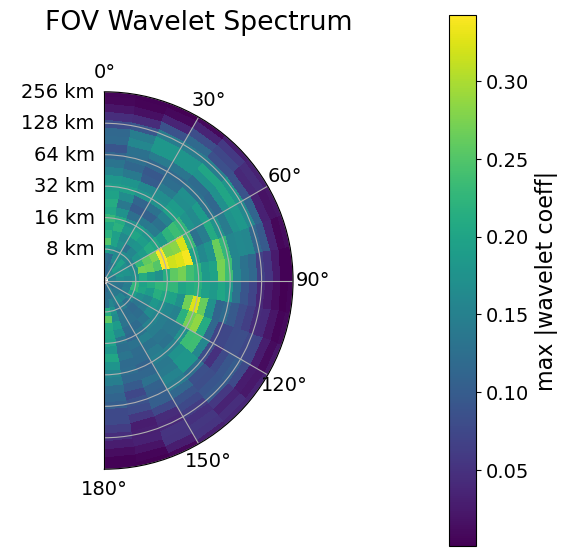

[Clusters-only] Cluster 0: amp=0.342, lamx=46.78, lamy=17.03, lam=16.00
[Clusters-only] Cluster 1: amp=0.338, lamx=78.68, lamy=28.64, lam=26.91
[Clusters-only] Cluster 2: amp=0.325, lamx=-184.28, lamy=32.49, lam=32.00
[Clusters-only] Cluster 3: amp=0.285, lamx=-111.26, lamy=40.50, lam=38.05
[Clusters-only] Cluster 4: amp=0.277, lamx=38.05, lamy=21.97, lam=19.03
[Clusters-only] Cluster 5: amp=0.273, lamx=309.92, lamy=54.65, lam=53.82
[Clusters-only] Cluster 6: amp=0.272, lamx=27.82, lamy=10.12, lam=9.51
[Clusters-only] Cluster 7: amp=0.271, lamx=130.31, lamy=22.98, lam=22.63
[Clusters-only] Cluster 8: amp=0.257, lamx=-9.66, lamy=54.79, lam=9.51
[Overlay] Cluster 0: amp=0.342, lamx=46.78, lamy=17.03, lam=16.00
[Overlay] Cluster 1: amp=0.338, lamx=78.68, lamy=28.64, lam=26.91
[Overlay] Cluster 2: amp=0.325, lamx=-184.28, lamy=32.49, lam=32.00
[Overlay] Cluster 3: amp=0.285, lamx=-111.26, lamy=40.50, lam=38.05
[Overlay] Cluster 4: amp=0.277, lamx=38.05, lamy=21.97, lam=19.03
[Overlay] Clus

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.39307414548232616 idx= (np.int64(8), np.int64(6), np.int64(28), np.int64(88))
selected elements: 59382
------------
cluster= 1
amplitude= 0.343788884608237 idx= (np.int64(11), np.int64(7), np.int64(96), np.int64(103))
selected elements: 35768
------------
cluster= 2
amplitude= 0.3287733582716213 idx= (np.int64(12), np.int64(10), np.int64(142), np.int64(47))
selected elements: 54317
------------
cluster= 3
amplitude= 0.3045681802537944 idx= (np.int64(13), np.int64(11), np.int64(129), np.int64(49))
selected elements: 29440
------------
cluster= 4
amplitude= 0.29549016614281604 idx= (np.int64(6), np.int64(6), np.int64(32), np.int64(70))
selected elements: 3655
------------
cluster= 5
amplitude= 0.2846651251232545 idx= (np.int64(4), np.int64(10), np.int64(28), np.int64(150))
selected elements: 2111
------------
cluster= 6
amplitude= 0.28019125352551144 idx= (np.int64(15), np.int64(7), np.int64(124), np.int64(116))
selected elements: 108203
------------


C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 86.65it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


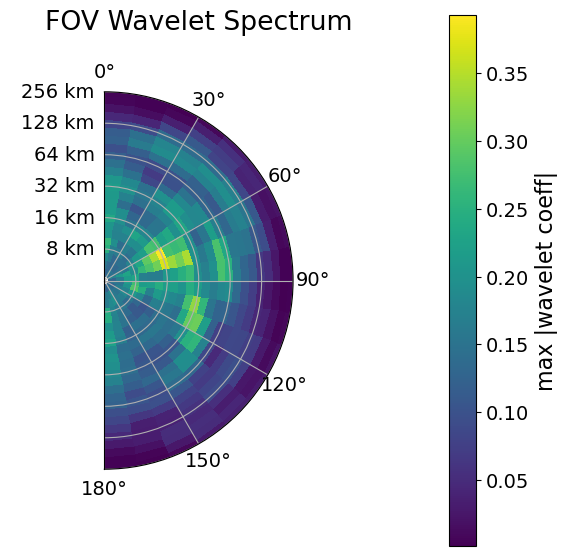

[Clusters-only] Cluster 0: amp=0.393, lamx=32.00, lamy=18.48, lam=16.00
[Clusters-only] Cluster 1: amp=0.344, lamx=78.68, lamy=28.64, lam=26.91
[Clusters-only] Cluster 2: amp=0.329, lamx=-184.28, lamy=32.49, lam=32.00
[Clusters-only] Cluster 3: amp=0.305, lamx=-111.26, lamy=40.50, lam=38.05
[Clusters-only] Cluster 4: amp=0.295, lamx=22.63, lamy=13.06, lam=11.31
[Clusters-only] Cluster 5: amp=0.285, lamx=-46.07, lamy=8.12, lam=8.00
[Clusters-only] Cluster 6: amp=0.280, lamx=157.35, lamy=57.27, lam=53.82
[Clusters-only] Cluster 7: amp=0.265, lamx=45.25, lamy=26.13, lam=22.63
[Clusters-only] Cluster 8: amp=0.262, lamx=9.51, lamy=inf, lam=9.51
[Overlay] Cluster 0: amp=0.393, lamx=32.00, lamy=18.48, lam=16.00
[Overlay] Cluster 1: amp=0.344, lamx=78.68, lamy=28.64, lam=26.91
[Overlay] Cluster 2: amp=0.329, lamx=-184.28, lamy=32.49, lam=32.00
[Overlay] Cluster 3: amp=0.305, lamx=-111.26, lamy=40.50, lam=38.05
[Overlay] Cluster 4: amp=0.295, lamx=22.63, lamy=13.06, lam=11.31
[Overlay] Cluster 

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.4504729489954289 idx= (np.int64(8), np.int64(6), np.int64(30), np.int64(88))
selected elements: 61523
------------
cluster= 1
amplitude= 0.35157705532011374 idx= (np.int64(11), np.int64(7), np.int64(105), np.int64(81))
selected elements: 48114
------------
cluster= 2
amplitude= 0.34143144156275396 idx= (np.int64(12), np.int64(10), np.int64(146), np.int64(47))
selected elements: 113983
------------
cluster= 3
amplitude= 0.3006996133397119 idx= (np.int64(6), np.int64(6), np.int64(27), np.int64(69))
selected elements: 2758
------------
cluster= 4
amplitude= 0.28202574564539956 idx= (np.int64(6), np.int64(17), np.int64(269), np.int64(71))
selected elements: 3870
------------
cluster= 5
amplitude= 0.27033827218310497 idx= (np.int64(15), np.int64(8), np.int64(125), np.int64(75))
selected elements: 99848
------------
cluster= 6
amplitude= 0.27000633598349905 idx= (np.int64(5), np.int64(10), np.int64(31), np.int64(148))
selected elements: 2391
------------


C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 81.89it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


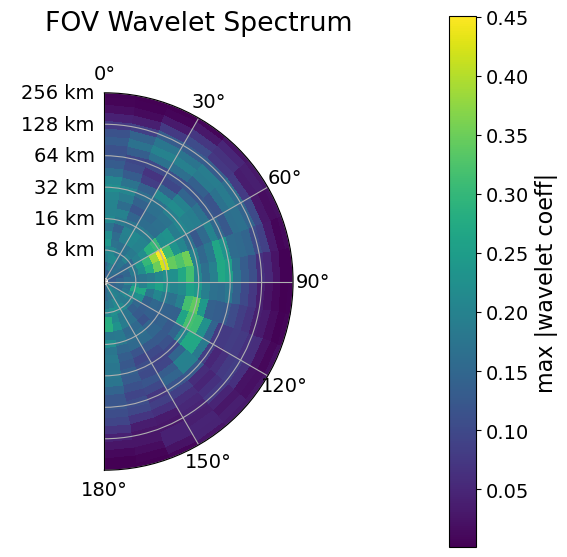

[Clusters-only] Cluster 0: amp=0.450, lamx=32.00, lamy=18.48, lam=16.00
[Clusters-only] Cluster 1: amp=0.352, lamx=78.68, lamy=28.64, lam=26.91
[Clusters-only] Cluster 2: amp=0.341, lamx=-184.28, lamy=32.49, lam=32.00
[Clusters-only] Cluster 3: amp=0.301, lamx=22.63, lamy=13.06, lam=11.31
[Clusters-only] Cluster 4: amp=0.282, lamx=-11.49, lamy=65.15, lam=11.31
[Clusters-only] Cluster 5: amp=0.270, lamx=309.92, lamy=54.65, lam=53.82
[Clusters-only] Cluster 6: amp=0.270, lamx=-54.79, lamy=9.66, lam=9.51
[Clusters-only] Cluster 7: amp=0.260, lamx=219726090060038048.00, lamy=13.45, lam=13.45
[Overlay] Cluster 0: amp=0.450, lamx=32.00, lamy=18.48, lam=16.00
[Overlay] Cluster 1: amp=0.352, lamx=78.68, lamy=28.64, lam=26.91
[Overlay] Cluster 2: amp=0.341, lamx=-184.28, lamy=32.49, lam=32.00
[Overlay] Cluster 3: amp=0.301, lamx=22.63, lamy=13.06, lam=11.31
[Overlay] Cluster 4: amp=0.282, lamx=-11.49, lamy=65.15, lam=11.31
[Overlay] Cluster 5: amp=0.270, lamx=309.92, lamy=54.65, lam=53.82
[Over

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.40537335800963936 idx= (np.int64(8), np.int64(6), np.int64(29), np.int64(87))
selected elements: 59032
------------
cluster= 1
amplitude= 0.38679117301291743 idx= (np.int64(11), np.int64(7), np.int64(107), np.int64(67))
selected elements: 75730
------------
cluster= 2
amplitude= 0.3624485005475466 idx= (np.int64(12), np.int64(10), np.int64(154), np.int64(51))
selected elements: 103306
------------
cluster= 3
amplitude= 0.27257969019252715 idx= (np.int64(6), np.int64(6), np.int64(28), np.int64(64))
selected elements: 2589
------------
cluster= 4
amplitude= 0.25790683622875027 idx= (np.int64(15), np.int64(7), np.int64(119), np.int64(133))
selected elements: 97853


C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 91.56it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


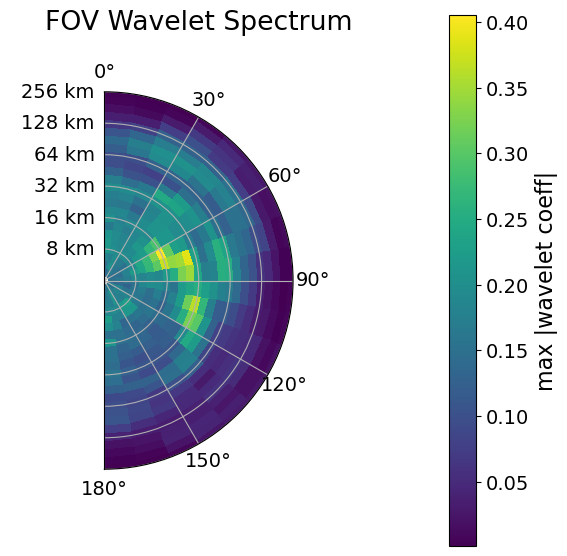

[Clusters-only] Cluster 0: amp=0.405, lamx=32.00, lamy=18.48, lam=16.00
[Clusters-only] Cluster 1: amp=0.387, lamx=78.68, lamy=28.64, lam=26.91
[Clusters-only] Cluster 2: amp=0.362, lamx=-184.28, lamy=32.49, lam=32.00
[Clusters-only] Cluster 3: amp=0.273, lamx=22.63, lamy=13.06, lam=11.31
[Clusters-only] Cluster 4: amp=0.258, lamx=157.35, lamy=57.27, lam=53.82
[Overlay] Cluster 0: amp=0.405, lamx=32.00, lamy=18.48, lam=16.00
[Overlay] Cluster 1: amp=0.387, lamx=78.68, lamy=28.64, lam=26.91
[Overlay] Cluster 2: amp=0.362, lamx=-184.28, lamy=32.49, lam=32.00
[Overlay] Cluster 3: amp=0.273, lamx=22.63, lamy=13.06, lam=11.31
[Overlay] Cluster 4: amp=0.258, lamx=157.35, lamy=57.27, lam=53.82
Saved: TempOH_caun1180_preview.png, TempOH_caun1180_background.png, TempOH_caun1180_cwt.png, TempOH_caun1180_fov_spectrum.png, TempOH_caun1180_clusters.png, TempOH_caun1180_clusters_overlay.png

=== Processing TempOH_caun1181.tif ===
[Full] mean: 21176.07
[Full] sigma: 3918.03
[Full] Dynamic range: [192

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.4575721145898396 idx= (np.int64(8), np.int64(6), np.int64(29), np.int64(79))
selected elements: 97702
------------
cluster= 1
amplitude= 0.36321898628369353 idx= (np.int64(11), np.int64(8), np.int64(49), np.int64(72))
selected elements: 79026
------------
cluster= 2
amplitude= 0.3591157430828678 idx= (np.int64(12), np.int64(10), np.int64(167), np.int64(45))
selected elements: 103479
------------
cluster= 3
amplitude= 0.3542282445321112 idx= (np.int64(5), np.int64(0), np.int64(275), np.int64(64))
selected elements: 6551
------------
cluster= 4
amplitude= 0.3194098449898009 idx= (np.int64(5), np.int64(17), np.int64(271), np.int64(64))
selected elements: 4140
------------
cluster= 5
amplitude= 0.2626798886658245 idx= (np.int64(8), np.int64(9), np.int64(145), np.int64(10))
selected elements: 7736
------------
cluster= 6
amplitude= 0.2562124216167036 idx= (np.int64(4), np.int64(9), np.int64(17), np.int64(139))
selected elements: 1086
------------
cluster

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 58.38it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


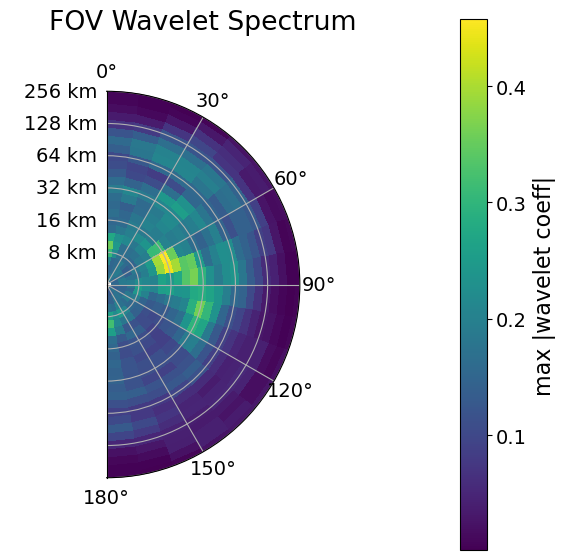

[Clusters-only] Cluster 0: amp=0.458, lamx=32.00, lamy=18.48, lam=16.00
[Clusters-only] Cluster 1: amp=0.363, lamx=154.96, lamy=27.32, lam=26.91
[Clusters-only] Cluster 2: amp=0.359, lamx=-184.28, lamy=32.49, lam=32.00
[Clusters-only] Cluster 3: amp=0.354, lamx=9.51, lamy=inf, lam=9.51
[Clusters-only] Cluster 4: amp=0.319, lamx=-9.66, lamy=54.79, lam=9.51
[Clusters-only] Cluster 5: amp=0.263, lamx=261299829651125920.00, lamy=16.00, lam=16.00
[Clusters-only] Cluster 6: amp=0.256, lamx=130649914825562960.00, lamy=8.00, lam=8.00
[Clusters-only] Cluster 7: amp=0.255, lamx=49.68, lamy=59.20, lam=38.05
[Overlay] Cluster 0: amp=0.458, lamx=32.00, lamy=18.48, lam=16.00
[Overlay] Cluster 1: amp=0.363, lamx=154.96, lamy=27.32, lam=26.91
[Overlay] Cluster 2: amp=0.359, lamx=-184.28, lamy=32.49, lam=32.00
[Overlay] Cluster 3: amp=0.354, lamx=9.51, lamy=inf, lam=9.51
[Overlay] Cluster 4: amp=0.319, lamx=-9.66, lamy=54.79, lam=9.51
[Overlay] Cluster 5: amp=0.263, lamx=261299829651125920.00, lamy=16.

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.44304934968014 idx= (np.int64(8), np.int64(7), np.int64(34), np.int64(74))
selected elements: 96653
------------
cluster= 1
amplitude= 0.4076447419097061 idx= (np.int64(12), np.int64(10), np.int64(195), np.int64(36))
selected elements: 167197
------------
cluster= 2
amplitude= 0.3982740825417231 idx= (np.int64(11), np.int64(8), np.int64(47), np.int64(66))
selected elements: 80605
------------
cluster= 3
amplitude= 0.33940777712350373 idx= (np.int64(5), np.int64(0), np.int64(278), np.int64(70))
selected elements: 5030
------------
cluster= 4
amplitude= 0.333528355777416 idx= (np.int64(5), np.int64(17), np.int64(272), np.int64(66))
selected elements: 6936
------------
cluster= 5
amplitude= 0.30997206720724085 idx= (np.int64(10), np.int64(9), np.int64(247), np.int64(16))
selected elements: 25425
------------
cluster= 6
amplitude= 0.2911933472205547 idx= (np.int64(6), np.int64(6), np.int64(22), np.int64(57))
selected elements: 3121
------------
cluster=

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 86.71it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


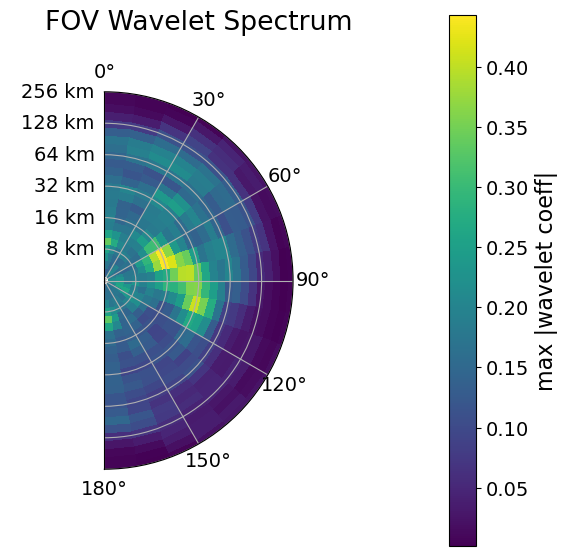

[Clusters-only] Cluster 0: amp=0.443, lamx=46.78, lamy=17.03, lam=16.00
[Clusters-only] Cluster 1: amp=0.408, lamx=-184.28, lamy=32.49, lam=32.00
[Clusters-only] Cluster 2: amp=0.398, lamx=154.96, lamy=27.32, lam=26.91
[Clusters-only] Cluster 3: amp=0.339, lamx=9.51, lamy=inf, lam=9.51
[Clusters-only] Cluster 4: amp=0.334, lamx=-9.66, lamy=54.79, lam=9.51
[Clusters-only] Cluster 5: amp=0.310, lamx=369533762938401664.00, lamy=22.63, lam=22.63
[Clusters-only] Cluster 6: amp=0.291, lamx=22.63, lamy=13.06, lam=11.31
[Clusters-only] Cluster 7: amp=0.288, lamx=261299829651125920.00, lamy=16.00, lam=16.00
[Clusters-only] Cluster 8: amp=0.284, lamx=109.57, lamy=19.32, lam=19.03
[Overlay] Cluster 0: amp=0.443, lamx=46.78, lamy=17.03, lam=16.00
[Overlay] Cluster 1: amp=0.408, lamx=-184.28, lamy=32.49, lam=32.00
[Overlay] Cluster 2: amp=0.398, lamx=154.96, lamy=27.32, lam=26.91
[Overlay] Cluster 3: amp=0.339, lamx=9.51, lamy=inf, lam=9.51
[Overlay] Cluster 4: amp=0.334, lamx=-9.66, lamy=54.79, la

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.4491411703322253 idx= (np.int64(12), np.int64(10), np.int64(207), np.int64(33))
selected elements: 264989
------------
cluster= 1
amplitude= 0.4307874512608351 idx= (np.int64(11), np.int64(8), np.int64(52), np.int64(61))
selected elements: 134084
------------
cluster= 2
amplitude= 0.41154416781770015 idx= (np.int64(8), np.int64(7), np.int64(34), np.int64(69))
selected elements: 14366
------------
cluster= 3
amplitude= 0.3157324413219467 idx= (np.int64(10), np.int64(8), np.int64(248), np.int64(25))
selected elements: 16157
------------
cluster= 4
amplitude= 0.29711731496523897 idx= (np.int64(13), np.int64(10), np.int64(42), np.int64(79))
selected elements: 11506
------------
cluster= 5
amplitude= 0.29346366272435215 idx= (np.int64(5), np.int64(17), np.int64(275), np.int64(77))
selected elements: 3588
------------
cluster= 6
amplitude= 0.2750953602384741 idx= (np.int64(9), np.int64(8), np.int64(142), np.int64(16))
selected elements: 5564
------------


C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 88.89it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


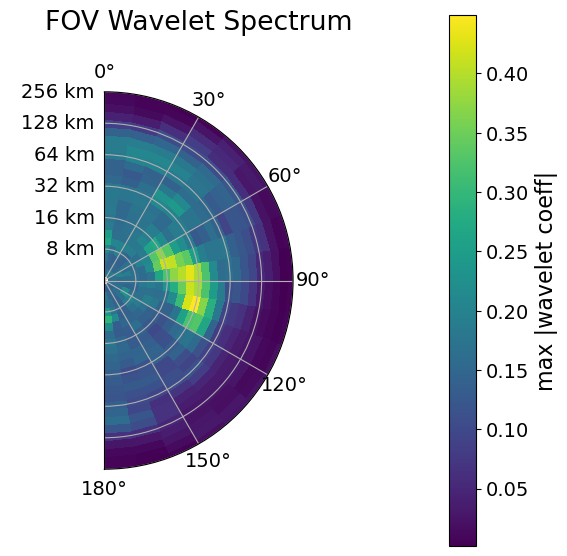

[Clusters-only] Cluster 0: amp=0.449, lamx=-184.28, lamy=32.49, lam=32.00
[Clusters-only] Cluster 1: amp=0.431, lamx=154.96, lamy=27.32, lam=26.91
[Clusters-only] Cluster 2: amp=0.412, lamx=46.78, lamy=17.03, lam=16.00
[Clusters-only] Cluster 3: amp=0.316, lamx=130.31, lamy=22.98, lam=22.63
[Clusters-only] Cluster 4: amp=0.297, lamx=-219.15, lamy=38.64, lam=38.05
[Clusters-only] Cluster 5: amp=0.293, lamx=-9.66, lamy=54.79, lam=9.51
[Clusters-only] Cluster 6: amp=0.275, lamx=109.57, lamy=19.32, lam=19.03
[Clusters-only] Cluster 7: amp=0.270, lamx=9.51, lamy=inf, lam=9.51
[Clusters-only] Cluster 8: amp=0.260, lamx=20.93, lamy=17.56, lam=13.45
[Overlay] Cluster 0: amp=0.449, lamx=-184.28, lamy=32.49, lam=32.00
[Overlay] Cluster 1: amp=0.431, lamx=154.96, lamy=27.32, lam=26.91
[Overlay] Cluster 2: amp=0.412, lamx=46.78, lamy=17.03, lam=16.00
[Overlay] Cluster 3: amp=0.316, lamx=130.31, lamy=22.98, lam=22.63
[Overlay] Cluster 4: amp=0.297, lamx=-219.15, lamy=38.64, lam=38.05
[Overlay] Clus

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.49584781735087635 idx= (np.int64(11), np.int64(8), np.int64(62), np.int64(48))
selected elements: 368547
------------
cluster= 1
amplitude= 0.4041940715248625 idx= (np.int64(11), np.int64(9), np.int64(225), np.int64(37))
selected elements: 56714
------------
cluster= 2
amplitude= 0.3188195634014433 idx= (np.int64(13), np.int64(10), np.int64(219), np.int64(30))
selected elements: 20620
------------
cluster= 3
amplitude= 0.3125902385647628 idx= (np.int64(6), np.int64(0), np.int64(281), np.int64(69))
selected elements: 4905
------------
cluster= 4
amplitude= 0.31095354615413173 idx= (np.int64(7), np.int64(7), np.int64(29), np.int64(77))
selected elements: 8466
------------
cluster= 5
amplitude= 0.2959222165683534 idx= (np.int64(5), np.int64(17), np.int64(279), np.int64(79))
selected elements: 2484
------------
cluster= 6
amplitude= 0.27578326380567375 idx= (np.int64(14), np.int64(11), np.int64(217), np.int64(56))
selected elements: 18732
------------
c

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 73.80it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


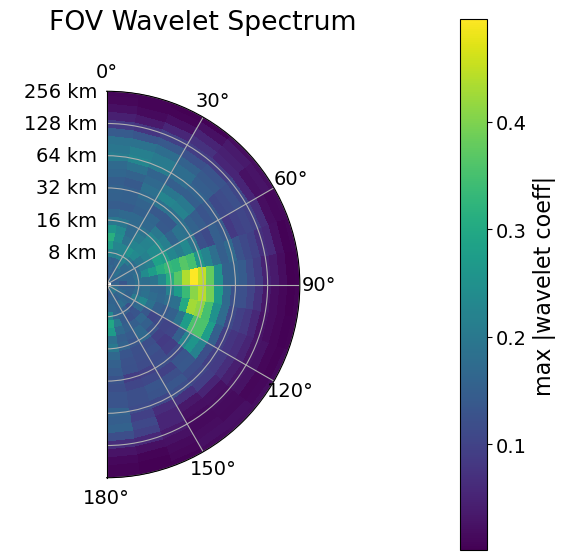

[Clusters-only] Cluster 0: amp=0.496, lamx=154.96, lamy=27.32, lam=26.91
[Clusters-only] Cluster 1: amp=0.404, lamx=439452180120076096.00, lamy=26.91, lam=26.91
[Clusters-only] Cluster 2: amp=0.319, lamx=-219.15, lamy=38.64, lam=38.05
[Clusters-only] Cluster 3: amp=0.313, lamx=11.31, lamy=inf, lam=11.31
[Clusters-only] Cluster 4: amp=0.311, lamx=39.34, lamy=14.32, lam=13.45
[Clusters-only] Cluster 5: amp=0.296, lamx=-9.66, lamy=54.79, lam=9.51
[Clusters-only] Cluster 6: amp=0.276, lamx=-132.32, lamy=48.16, lam=45.25
[Clusters-only] Cluster 7: amp=0.273, lamx=-78.68, lamy=28.64, lam=26.91
[Clusters-only] Cluster 8: amp=0.268, lamx=310739616570117888.00, lamy=19.03, lam=19.03
[Overlay] Cluster 0: amp=0.496, lamx=154.96, lamy=27.32, lam=26.91
[Overlay] Cluster 1: amp=0.404, lamx=439452180120076096.00, lamy=26.91, lam=26.91
[Overlay] Cluster 2: amp=0.319, lamx=-219.15, lamy=38.64, lam=38.05
[Overlay] Cluster 3: amp=0.313, lamx=11.31, lamy=inf, lam=11.31
[Overlay] Cluster 4: amp=0.311, lamx

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.527939779575179 idx= (np.int64(11), np.int64(8), np.int64(62), np.int64(45))
selected elements: 233430
------------
cluster= 1
amplitude= 0.4908560073981589 idx= (np.int64(12), np.int64(9), np.int64(53), np.int64(43))
selected elements: 172351
------------
cluster= 2
amplitude= 0.381517901613774 idx= (np.int64(6), np.int64(0), np.int64(271), np.int64(71))
selected elements: 13255
------------
cluster= 3
amplitude= 0.3170985628813504 idx= (np.int64(8), np.int64(7), np.int64(28), np.int64(60))
selected elements: 10741
------------
cluster= 4
amplitude= 0.3147279097461308 idx= (np.int64(6), np.int64(17), np.int64(273), np.int64(74))
selected elements: 3796
------------
cluster= 5
amplitude= 0.2959203707738218 idx= (np.int64(5), np.int64(1), np.int64(239), np.int64(104))
selected elements: 3213
------------
cluster= 6
amplitude= 0.29250080504909315 idx= (np.int64(13), np.int64(12), np.int64(172), np.int64(50))
selected elements: 59120
------------
clust

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|███████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 109.88it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


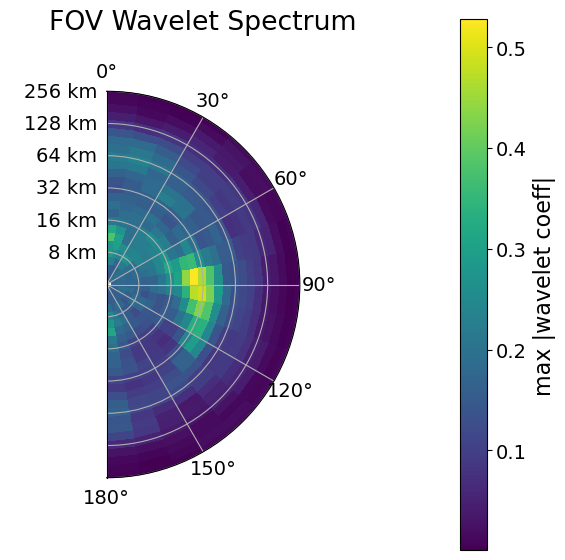

[Clusters-only] Cluster 0: amp=0.528, lamx=154.96, lamy=27.32, lam=26.91
[Clusters-only] Cluster 1: amp=0.491, lamx=522599659302251840.00, lamy=32.00, lam=32.00
[Clusters-only] Cluster 2: amp=0.382, lamx=11.31, lamy=inf, lam=11.31
[Clusters-only] Cluster 3: amp=0.317, lamx=46.78, lamy=17.03, lam=16.00
[Clusters-only] Cluster 4: amp=0.315, lamx=-11.49, lamy=65.15, lam=11.31
[Clusters-only] Cluster 5: amp=0.296, lamx=9.66, lamy=54.79, lam=9.51
[Clusters-only] Cluster 6: amp=0.293, lamx=-76.11, lamy=43.94, lam=38.05
[Clusters-only] Cluster 7: amp=0.291, lamx=8.00, lamy=inf, lam=8.00
[Clusters-only] Cluster 8: amp=0.272, lamx=9.24, lamy=16.00, lam=8.00
[Overlay] Cluster 0: amp=0.528, lamx=154.96, lamy=27.32, lam=26.91
[Overlay] Cluster 1: amp=0.491, lamx=522599659302251840.00, lamy=32.00, lam=32.00
[Overlay] Cluster 2: amp=0.382, lamx=11.31, lamy=inf, lam=11.31
[Overlay] Cluster 3: amp=0.317, lamx=46.78, lamy=17.03, lam=16.00
[Overlay] Cluster 4: amp=0.315, lamx=-11.49, lamy=65.15, lam=11.

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.5752665173468868 idx= (np.int64(11), np.int64(8), np.int64(61), np.int64(45))
selected elements: 418724
------------
cluster= 1
amplitude= 0.33208462328308214 idx= (np.int64(9), np.int64(9), np.int64(115), np.int64(14))
selected elements: 10418
------------
cluster= 2
amplitude= 0.3135562206684733 idx= (np.int64(4), np.int64(0), np.int64(8), np.int64(25))
selected elements: 4351
------------
cluster= 3
amplitude= 0.2903935362700914 idx= (np.int64(8), np.int64(6), np.int64(17), np.int64(56))
selected elements: 8891
------------
cluster= 4
amplitude= 0.2858196920498663 idx= (np.int64(5), np.int64(1), np.int64(240), np.int64(110))
selected elements: 3580
------------
cluster= 5
amplitude= 0.27829674498422957 idx= (np.int64(6), np.int64(0), np.int64(274), np.int64(77))
selected elements: 3702
------------
cluster= 6
amplitude= 0.26670701159897164 idx= (np.int64(6), np.int64(17), np.int64(271), np.int64(81))
selected elements: 1807
------------
cluster= 

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 88.61it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


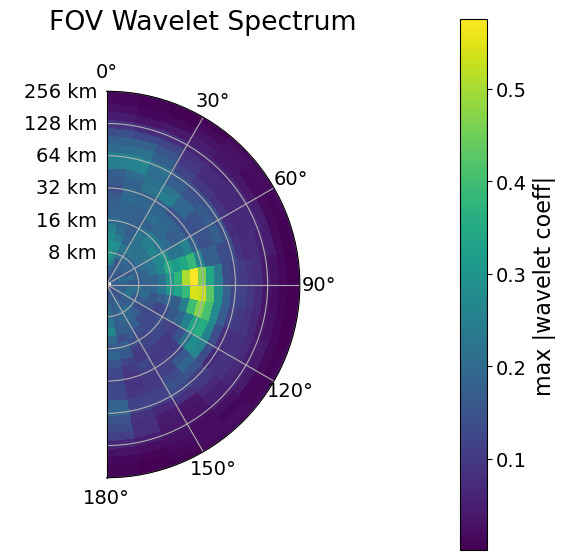

[Clusters-only] Cluster 0: amp=0.575, lamx=154.96, lamy=27.32, lam=26.91
[Clusters-only] Cluster 1: amp=0.332, lamx=310739616570117888.00, lamy=19.03, lam=19.03
[Clusters-only] Cluster 2: amp=0.314, lamx=8.00, lamy=inf, lam=8.00
[Clusters-only] Cluster 3: amp=0.290, lamx=32.00, lamy=18.48, lam=16.00
[Clusters-only] Cluster 4: amp=0.286, lamx=9.66, lamy=54.79, lam=9.51
[Clusters-only] Cluster 5: amp=0.278, lamx=11.31, lamy=inf, lam=11.31
[Clusters-only] Cluster 6: amp=0.267, lamx=-11.49, lamy=65.15, lam=11.31
[Clusters-only] Cluster 7: amp=0.266, lamx=64.99, lamy=368.56, lam=64.00
[Clusters-only] Cluster 8: amp=0.266, lamx=20.93, lamy=17.56, lam=13.45
[Overlay] Cluster 0: amp=0.575, lamx=154.96, lamy=27.32, lam=26.91
[Overlay] Cluster 1: amp=0.332, lamx=310739616570117888.00, lamy=19.03, lam=19.03
[Overlay] Cluster 2: amp=0.314, lamx=8.00, lamy=inf, lam=8.00
[Overlay] Cluster 3: amp=0.290, lamx=32.00, lamy=18.48, lam=16.00
[Overlay] Cluster 4: amp=0.286, lamx=9.66, lamy=54.79, lam=9.51


In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Batch wavelet pipeline

For each TIFF file in FOLDER_PATH:

  Full TIFF -> ROI -> background removal -> wavelet clusters

Produces, per input image (using its stem as prefix):

  <stem>_preview.png            # full TIFF preview (mean ± 0.5σ) with ROI rectangle
  <stem>_background.png         # 4-panel background figure:
                                #   - original (median-sub)
                                #   - background (plane + first Fourier)
                                #   - remaining
                                #   - remaining with edge taper, spikes removed
  <stem>_cwt.png                # Wavelet decomposition summary (utils.plot_decomposition2d)
  <stem>_fov_spectrum.png       # FOV wavelet spectrum (orientation vs wavelength)
  <stem>_clusters.png           # 9 standalone wavelet clusters (reconstructed fields)
  <stem>_clusters_overlay.png   # 9 overlay clusters on tapered remaining field
"""

from __future__ import annotations
from typing import Tuple, Optional
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------

# Folder containing TIFF files
FOLDER_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Nov7th1150"
# Output folder (created if not exists). If None, uses "<FOLDER_PATH>/wavelet_output"
OUTPUT_SUBDIR = "wavelet_output"

# ROI (pixel slices) for analysis. Set to None to use full image.
X_SLICE: Optional[slice] = slice(12, 308)
Y_SLICE: Optional[slice] = slice(18, 248)

# Single sigma factor: mean ± 0.5σ (computed once per image on full field)
SIGMA_FACTOR = 0.5
APPLY_RANGE_FILTER = True   # use that [lo, hi] range for ROI filtering

# How to fill invalid pixels before CWT (to keep rectangular grid)
# choices: "median", "mean", "zero"
FILL_INVALID_FOR_CWT = "median"

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 1        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 7            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 4
DJ = 1/4
JS = 25
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.2           # thr for identify_cluster2d

# Whether to call plt.show() (for batch script this is usually False)
SHOW_PLOTS = False

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# Helpers
# --------------------------
def load_tiff(path: str) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def make_range_mask(Z: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """True where value is inside [lo, hi]."""
    return (Z >= lo) & (Z <= hi)


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def fill_invalid(Z: np.ndarray, valid_mask: Optional[np.ndarray], how: str) -> np.ndarray:
    """Fill invalid pixels to keep rectangular grid before CWT."""
    out = Z.copy()
    if valid_mask is None:
        return out
    inv = ~valid_mask
    if not np.any(inv):
        return out
    if how == "median":
        val = float(np.median(out[~inv])) if np.any(~inv) else float(np.median(out))
    elif how == "mean":
        val = float(np.mean(out[~inv])) if np.any(~inv) else float(np.mean(out))
    elif how == "zero":
        val = 0.0
    else:
        raise ValueError("FILL_INVALID_FOR_CWT must be 'median', 'mean', or 'zero'")
    out[inv] = val
    return out


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.

    Parameters
    ----------
    Z : 2D array
    size : int
        Window size for local median (3, 5, ...)
    k : float
        Threshold in units of local MAD (~sigma). Larger = more tolerant.

    Returns
    -------
    2D array, same shape as Z
    """
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      interior stays ~1
      transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Core pipeline for one file
# --------------------------
def process_file(tiff_path: Path, out_dir: Path) -> None:
    """Run the full pipeline on one TIFF and save all figures."""
    print(f"\n=== Processing {tiff_path.name} ===")

    # 1) Load full TIFF
    full = load_tiff(str(tiff_path))
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    # 2) Compute mean/std once on the full image, use ±0.5σ everywhere
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean: {center:.2f}")
    print(f"[Full] sigma: {sigma:.2f}")
    print(f"[Full] Dynamic range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # 3) Full-image preview with that same range, and ROI rectangle
    mask_full = make_range_mask(full, lo, hi)
    preview = full.copy().astype(float)
    preview[~mask_full] = np.nan

    vals_full = preview[np.isfinite(preview)]
    if vals_full.size > 0:
        print(f"[Full] In-range count: {vals_full.size}")
        print(f"[Full] In-range min/max: {np.nanmin(vals_full):.2f} / {np.nanmax(vals_full):.2f}")
        p5f, p50f, p95f = np.nanpercentile(vals_full, [5, 50, 95])
        print(f"[Full] In-range percentiles 5/50/95: {p5f:.2f} / {p50f:.2f} / {p95f:.2f}")
    else:
        print("[Full] Warning: no pixels within mean ± 0.5 sigma")

    disp_prev = np.clip(preview, lo, hi)

    # Flip y for display
    y_full_flip = y_full[::-1]

    fig_prev, ax_prev = plt.subplots()
    im_prev = ax_prev.pcolormesh(
        x_full,
        y_full_flip,
        disp_prev,
        shading="auto",
        cmap="gray",
        vmin=lo,
        vmax=hi,
    )
    cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
    cb_prev.set_label("Intensity (a.u.)")
    ax_prev.set_xlabel("x (pixels)")
    ax_prev.set_ylabel("y (pixels)")
    ax_prev.set_title(f"Full TIFF masked to mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}")
    ax_prev.set_aspect("equal", adjustable="box")

    # ROI rectangle in full-image coordinates
    ysl_full = Y_SLICE if Y_SLICE is not None else slice(0, ny_full)
    xsl_full = X_SLICE if X_SLICE is not None else slice(0, nx_full)

    x0 = 0 if xsl_full.start is None else xsl_full.start
    x1 = nx_full if xsl_full.stop is None else xsl_full.stop
    y0 = 0 if ysl_full.start is None else ysl_full.start
    y1 = ny_full if ysl_full.stop is None else ysl_full.stop

    # Map to flipped-y display coords: [y0, y1) -> [ny_full - y1, ny_full - y0)
    y0_disp = ny_full - y1
    y1_disp = ny_full - y0

    rect = patches.Rectangle(
        (x0, y0_disp),
        x1 - x0,
        y1_disp - y0_disp,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax_prev.add_patch(rect)

    out_preview = out_dir / f"{tiff_path.stem}_preview.png"
    fig_prev.savefig(out_preview, dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show(fig_prev)
    plt.close(fig_prev)

    # 4) Clip to ROI
    ysl = Y_SLICE if Y_SLICE is not None else slice(None, None)
    xsl = X_SLICE if X_SLICE is not None else slice(None, None)

    raw = full[ysl, xsl]
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]   # flip y for display

    print(f"[ROI] shape: {raw.shape}")

    # 5) Range filter for ROI, using the SAME [lo, hi] from full image
    mask = None
    if APPLY_RANGE_FILTER:
        mask = make_range_mask(raw, lo, hi)
        vals_roi = raw[mask]
        if vals_roi.size > 0:
            print(f"[ROI] In-range count: {vals_roi.size}")
            print(f"[ROI] In-range min/max: {np.nanmin(vals_roi):.2f} / {np.nanmax(vals_roi):.2f}")
            p5r, p50r, p95r = np.nanpercentile(vals_roi, [5, 50, 95])
            print(f"[ROI] In-range percentiles 5/50/95: {p5r:.2f} / {p50r:.2f} / {p95r:.2f}")
        else:
            print("[ROI] Warning: no pixels in [mean ± 0.5σ]")

    # 6) Prepare data for CWT: fill removed pixels to keep rectangular grid
    filled = fill_invalid(raw, mask, FILL_INVALID_FOR_CWT) if APPLY_RANGE_FILTER else raw

    # No despike here; we will despike after tapering.
    proc0 = filled.copy()

    # 7) Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # 8) Apply edge taper on remaining field (for CWT and plotting)
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Remove spikes AFTER tapering (optional)
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel
    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # 9) 4-panel background figure
    fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    axes_bg_flat = axs_bg.flatten()

    imgs_bg = [
        (orig_c, "Original (median-sub)"),
        (bg_c, "Background (plane + first Fourier)"),
        (rem_c, "Remaining = original - background"),
        (rem_tapered_c, "Remaining with edge taper (spikes removed)"),
    ]

    im_bg = None
    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im_bg = ax.pcolormesh(
            x1d,
            y1d,
            Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_aspect("equal")

    cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical",
                              fraction=0.04, pad=0.02)
    cbar_bg.set_label("Intensity (a.u.)")

    out_bg = out_dir / f"{tiff_path.stem}_background.png"
    fig_bg.savefig(out_bg, dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show(fig_bg)
    plt.close(fig_bg)

    # 10) Preprocess for CWT only (standardize + blur) on tapered + de-spiked field
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # 11) Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # 12) Overview CWT plot
    cmap_cwt = matplotlib.cm.turbo
    norm_cwt = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap_cwt.N
    )
    fig_cwt, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2,
                                            cmap=cmap_cwt, norm=norm_cwt)

    out_cwt = out_dir / f"{tiff_path.stem}_cwt.png"
    fig_cwt.savefig(out_cwt, dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show(fig_cwt)
    plt.close(fig_cwt)

    # 13) FOV wavelet spectrum
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")
    fig_fov = plt.gcf()
    out_fov = out_dir / f"{tiff_path.stem}_fov_spectrum.png"
    fig_fov.savefig(out_fov, dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show(fig_fov)
    plt.close(fig_fov)

    # Background image for overlays: tapered remaining (spikes removed), centered
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    # --------------------------
    # Figure 1: 9 standalone clusters
    # --------------------------
    fig1, axs1 = plt.subplots(3, 3, figsize=(12, 10))
    axes1_flat = axs1.flatten()

    opts_img_cluster = {"cmap": "RdBu_r", "vmin": -0.8, "vmax": 0.8, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes1_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes1_flat, biggest):
            # Reconstruct cluster
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]          # (s_idx, t_idx, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(rf"$\lambda$={_fmt(lam)}")
            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img_cluster)
            ax.set_aspect("equal", adjustable="box")

            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )

            print(
                f"[Clusters-only] Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # Hide unused axes
        for ax in axes1_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    for ax in axs1[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs1[:, 0]:
        ax.set_ylabel("y (pixels)")

    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }
    for i, ax in enumerate(axes1_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig1.tight_layout()
    out_clusters = out_dir / f"{tiff_path.stem}_clusters.png"
    fig1.savefig(out_clusters, dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show(fig1)
    plt.close(fig1)

    # --------------------------
    # Figure 2: 9 overlays (cluster on tapered field)
    # --------------------------
    fig2, axs2 = plt.subplots(3, 3, figsize=(12, 10))
    axes2_flat = axs2.flatten()

    if n_clusters == 0:
        for ax in axes2_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        cl_vmin, cl_vmax = -0.6, 0.6

        for ax, kcl in zip(axes2_flat, biggest):
            # Background: tapered remaining field (centered, spikes removed), grayscale
            ax.pcolormesh(
                x1d,
                y1d,
                bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            # Reconstruct cluster again
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(rf"$\lambda$={_fmt(lam)}")
            ax.set_aspect("equal", adjustable="box")

            print(
                f"[Overlay] Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # Hide unused axes
        for ax in axes2_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    for ax in axs2[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs2[:, 0]:
        ax.set_ylabel("y (pixels)")

    for i, ax in enumerate(axes2_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()
    out_overlay = out_dir / f"{tiff_path.stem}_clusters_overlay.png"
    fig2.savefig(out_overlay, dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show(fig2)
    plt.close(fig2)

    print(f"Saved: {out_preview.name}, {out_bg.name}, {out_cwt.name}, "
          f"{out_fov.name}, {out_clusters.name}, {out_overlay.name}")


# --------------------------
# Run over all TIFFs in folder
# --------------------------
def run_batch():
    folder = Path(FOLDER_PATH)
    if OUTPUT_SUBDIR is None:
        out_root = folder / "wavelet_output"
    else:
        out_root = folder / OUTPUT_SUBDIR
    out_root.mkdir(parents=True, exist_ok=True)

    tiffs = sorted(list(folder.glob("*.tif")) + list(folder.glob("*.tiff")))
    if not tiffs:
        print(f"No TIFF files found in {folder}")
        return

    print(f"Found {len(tiffs)} TIFF files in {folder}")
    print(f"Output will be saved in {out_root}")

    for t in tiffs:
        try:
            process_file(t, out_root)
        except Exception as e:
            print(f"Error processing {t.name}: {e}")


if __name__ == "__main__":
    run_batch()
